DAY 5: HYPERPARAMETER TUNING

📊 Experiment 1: How many trees?
   10 trees: 0.9561 (95.6%)
   50 trees: 0.9649 (96.5%)
  100 trees: 0.9649 (96.5%)
  200 trees: 0.9649 (96.5%)
  300 trees: 0.9649 (96.5%)
  500 trees: 0.9649 (96.5%)

📊 Experiment 2: How deep should trees be?
  depth=2    : 0.9649 (96.5%)
  depth=3    : 0.9649 (96.5%)
  depth=5    : 0.9649 (96.5%)
  depth=10   : 0.9649 (96.5%)
  depth=15   : 0.9649 (96.5%)
  depth=20   : 0.9649 (96.5%)
  depth=None : 0.9649 (96.5%)

📊 Experiment 3: Minimum samples to split?
  min_samples_split=  2: 0.9649 (96.5%)
  min_samples_split=  5: 0.9649 (96.5%)
  min_samples_split= 10: 0.9649 (96.5%)
  min_samples_split= 20: 0.9649 (96.5%)
  min_samples_split= 50: 0.9649 (96.5%)
  min_samples_split=100: 0.9649 (96.5%)


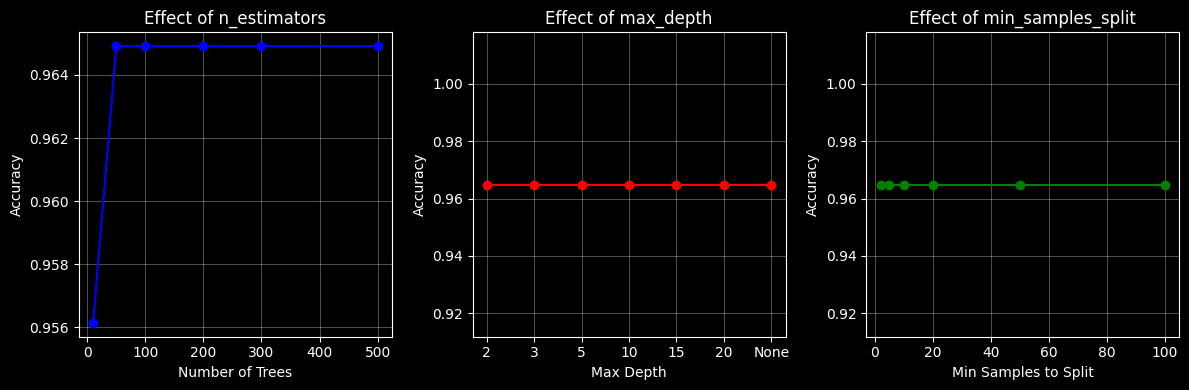


BEST HYPERPARAMETERS

✅ Optimized Random Forest Accuracy: 0.9649 (96.5%)

💡 INSIGHT:
  - More trees = better but diminishing returns after ~200
  - Max depth 5-10 prevents overfitting
  - Higher min_samples_split reduces overfitting


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

print("=" * 60)
print("DAY 5: HYPERPARAMETER TUNING")
print("=" * 60)

# Load data
data = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(
    data.data, data.target, test_size=0.2, random_state=42
)

# ============================================
# EXPERIMENT 1: Number of Trees (n_estimators)
# ============================================

print("\n📊 Experiment 1: How many trees?")
n_trees = [10, 50, 100, 200, 300, 500]
scores = []

for n in n_trees:
    rf = RandomForestClassifier(n_estimators=n, random_state=42)
    rf.fit(X_train, y_train)
    score = rf.score(X_test, y_test)
    scores.append(score)
    print(f"  {n:3d} trees: {score:.4f} ({score*100:.1f}%)")

# Plot
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.plot(n_trees, scores, 'bo-')
plt.xlabel('Number of Trees')
plt.ylabel('Accuracy')
plt.title('Effect of n_estimators')
plt.grid(True, alpha=0.3)

# ============================================
# EXPERIMENT 2: Max Depth
# ============================================

print("\n📊 Experiment 2: How deep should trees be?")
depths = [2, 3, 5, 10, 15, 20, None]
depth_scores = []

for d in depths:
    rf = RandomForestClassifier(max_depth=d, random_state=42)
    rf.fit(X_train, y_train)
    score = rf.score(X_test, y_test)
    depth_scores.append(score)
    print(f"  depth={str(d):5s}: {score:.4f} ({score*100:.1f}%)")

plt.subplot(1, 3, 2)
depth_labels = ['2', '3', '5', '10', '15', '20', 'None']
plt.plot(range(len(depths)), depth_scores, 'ro-')
plt.xticks(range(len(depths)), depth_labels)
plt.xlabel('Max Depth')
plt.ylabel('Accuracy')
plt.title('Effect of max_depth')
plt.grid(True, alpha=0.3)

# ============================================
# EXPERIMENT 3: Min Samples Split
# ============================================

print("\n📊 Experiment 3: Minimum samples to split?")
min_samples = [2, 5, 10, 20, 50, 100]
min_scores = []

for m in min_samples:
    rf = RandomForestClassifier(min_samples_split=m, random_state=42)
    rf.fit(X_train, y_train)
    score = rf.score(X_test, y_test)
    min_scores.append(score)
    print(f"  min_samples_split={m:3d}: {score:.4f} ({score*100:.1f}%)")

plt.subplot(1, 3, 3)
plt.plot(min_samples, min_scores, 'go-')
plt.xlabel('Min Samples to Split')
plt.ylabel('Accuracy')
plt.title('Effect of min_samples_split')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================
# BEST MODEL
# ============================================

print("\n" + "=" * 60)
print("BEST HYPERPARAMETERS")
print("=" * 60)

best_rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    random_state=42
)
best_rf.fit(X_train, y_train)
best_score = best_rf.score(X_test, y_test)

print(f"\n✅ Optimized Random Forest Accuracy: {best_score:.4f} ({best_score*100:.1f}%)")
print("\n💡 INSIGHT:")
print("  - More trees = better but diminishing returns after ~200")
print("  - Max depth 5-10 prevents overfitting")
print("  - Higher min_samples_split reduces overfitting")